In [2]:
import pandas as pd
df = pd.read_csv('data/정제데이터/구별데이터_스케일링.csv', encoding='cp949')
df.head(3)

,시군구,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),도시재생사업수
0,강남구,0.258356,0.891770,1.000000,0.50,0.285714,0.827140,1.000000,0.606061,0.0
1,강동구,0.518524,0.461778,0.601108,0.75,0.571429,0.715354,0.259889,0.525253,0.4
2,강북구,1.000000,0.241271,0.141629,0.25,0.571429,0.501950,0.066923,0.565657,0.6


# 환경불평등지수
- 기초수급자_인구밀도 + (1-인당녹지면적)

In [3]:
df['환경불평등지수'] = df.기초수급자_인구밀도 + (1- df.인당녹지면적)

In [4]:
df.head(3)

,시군구,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),도시재생사업수,환경불평등지수
0,강남구,0.258356,0.891770,1.000000,0.50,0.285714,0.827140,1.000000,0.606061,0.0,0.431216
1,강동구,0.518524,0.461778,0.601108,0.75,0.571429,0.715354,0.259889,0.525253,0.4,0.803171
2,강북구,1.000000,0.241271,0.141629,0.25,0.571429,0.501950,0.066923,0.565657,0.6,1.498050


In [8]:
data = df[['총공시지가평균','환경불평등지수']]

In [5]:
df

,시군구,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),도시재생사업수,환경불평등지수
0,강남구,0.258356,0.891770,1.000000,0.50,0.285714,0.827140,1.000000,0.606061,0.0,0.431216
1,강동구,0.518524,0.461778,0.601108,0.75,0.571429,0.715354,0.259889,0.525253,0.4,0.803171
2,강북구,1.000000,0.241271,0.141629,0.25,0.571429,0.501950,0.066923,0.565657,0.6,1.498050
3,강서구,0.460660,1.000000,0.906604,1.00,0.857143,1.000000,0.050196,0.464646,0.1,0.460660
4,관악구,0.806628,0.276906,0.116055,0.25,0.142857,0.337779,0.314431,0.252525,0.2,1.468850
5,광진구,0.573806,0.316486,0.266399,0.50,0.285714,0.371599,0.392770,0.585859,0.1,1.202206
6,구로구,0.553183,0.413605,0.458227,0.50,0.714286,0.503193,0.104274,0.585859,0.4,1.049989
7,금천구,0.512857,0.170871,0.149014,1.00,0.428571,0.000000,0.131990,0.676768,0.3,1.512857
8,노원구,0.784855,0.477565,0.433462,0.75,0.428571,0.557502,0.023756,0.141414,0.2,1.227353
9,도봉구,0.788059,0.195392,0.000000,0.25,0.285714,0.579902,0.000000,0.343434,0.4,1.208156


In [6]:
import dataframe_image as dfi

dfi.export(df, './image/구별데이터_스케일링_df.png', max_cols = -1, max_rows = -1)

# 엘보우 차트

C:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows wi

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(1, 10))

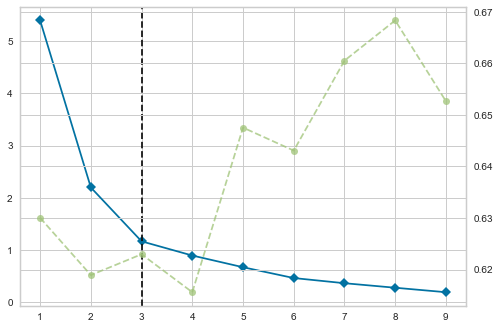

In [14]:
try:
    from IPython.display import Markdown as md
except ImportError:
    pass

from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,10))
visualizer.fit(data)

In [16]:
.savefig("엘보우챠트.png")

NameError: name 'plt' is not defined

# 군집화

In [17]:
from sklearn.cluster import KMeans

k = 3

# 그룹 수, random_state 설정
model = KMeans(n_clusters = k, random_state = 10)

# 정규화된 데이터에 학습
model.fit(data)

# 클러스터링 결과 각 데이터가 몇 번째 그룹에 속하는지 저장
df['cluster'] = model.fit_predict(data)

C:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# 시각화

Gulim


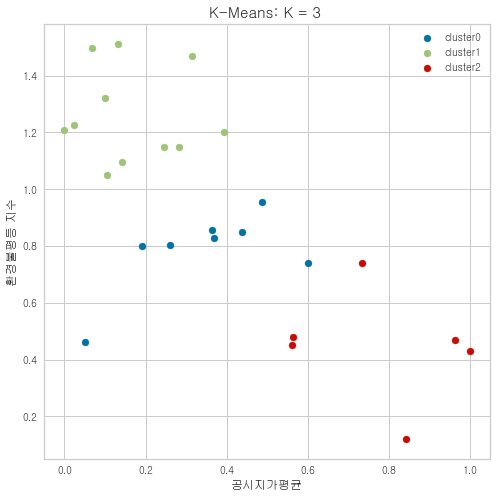

In [25]:
import matplotlib.pyplot as plt

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

plt.figure(figsize = (8, 8))

for i in range(k):
    plt.scatter(df.loc[df['cluster'] == i, '총공시지가평균'], df.loc[df['cluster'] == i, '환경불평등지수'], label = 'cluster' + str(i))

plt.legend()
plt.title('K-Means: K = %d '%k , size = 15)
plt.xlabel('공시지가평균', size = 12)
plt.ylabel('환경불평등 지수', size = 12)
plt.show()

In [27]:
.savefig("image/10-1K-Means.png")

NameError: name 'fig' is not defined

In [20]:
cluster_cnt = df.groupby('cluster').agg({'시군구':'count'}).reset_index()
cluster_des = df.groupby('cluster').mean().reset_index()

In [21]:
a = pd.merge(cluster_cnt,cluster_des)

In [22]:
a

,cluster,시군구,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),도시재생사업수,환경불평등지수
0,0,8,0.441444,0.440134,0.486750,0.531250,0.517857,0.654836,0.345050,0.566919,0.350000,0.786608
1,1,11,0.738463,0.332974,0.269569,0.522727,0.441558,0.476325,0.163785,0.475666,0.409091,1.262138
2,2,6,0.215733,0.330290,0.420833,0.500000,0.500000,0.766807,0.776749,0.468013,0.316667,0.448925


In [23]:
import dataframe_image as dfi

dfi.export(a, './image/K-mens_describe.png', max_cols = -1, max_rows = -1)

In [35]:
df[df.cluster==1].시군구.unique()

array(['강북구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구', '동대문구', '양천구',
       '은평구', '중랑구'], dtype=object)

# 실루엣 계수

In [36]:
from sklearn.metrics import silhouette_score
 
silhouette_score(data, df['cluster'], metric='euclidean')

0.4462190284128122

In [37]:
from sklearn.metrics import silhouette_samples

# 모든 개별 데이터에 실루엣 계수값을 구함. 
score_samples = silhouette_samples(data, df['cluster'])
print('silhouette_samples( ) return 값의 shape' , score_samples.shape)

# 실루엣 계수 컬럼 추가
df['silhouette_coeff'] = score_samples

# 모든 데이터의 평균 실루엣 계수값을 구함. 
average_score = silhouette_score(data, df['cluster'])
print(' Silhouette Analysis Score:'.format(average_score))

silhouette_samples( ) return 값의 shape (25,)
 Silhouette Analysis Score:


In [38]:
df.groupby('cluster')['silhouette_coeff'].mean()

cluster
0    0.463989
1    0.486337
2    0.348976
Name: silhouette_coeff, dtype: float64